# Day 01：隐藏层 —— 打破线性边界的魔法

> ☀️ 第二周 · 破局与复兴 · 第 1 天

上一周我们学到了单层感知机的致命弱点：**它只能画一条直线**。

XOR 问题让整个 AI 领域陷入了十几年的寒冬。直到人们想出了一个办法——**在输入和输出之间多加一层**。

这一层不直接连接输入输出，而是藏在「中间」，所以叫**隐藏层（Hidden Layer）**。

**今天的任务**：理解隐藏层如何让神经网络拥有「曲线思维」，从而打破线性的限制。

---

## 1. 单层感知机的困境回顾

还记得 XOR 的问题吗？用一条直线无论如何都没法把『同或』和『异或』分开：

```
  Y
  │  1          0
  │      ╲    ╱
  │       ╲  ╱
  │        ╳
  │       ╱  ╲
  │      ╱    ╲
  └──────────────── X
       0          1
       
  X=0,Y=0 -> 1 (同或)
  X=1,Y=1 -> 1 (同或)
  X=0,Y=1 -> 0 (异或)
  X=1,Y=0 -> 0 (异或)
```

一条直线最多只能切两刀，要表达 XOR 的「对角线」分类边界，需要**两条直线**。

---

## 2. 隐藏层的几何直觉

隐藏层的核心思想是：**把输入空间变换到另一个空间**。

想象一下：
- **输入空间**：一个平面，有四个点 (0,0)、(1,1)、(0,1)、(1,0)
- **隐藏层**：把每个点「搬到」新位置
- **新空间**：搬动后，点变得线性可分了！

这就像地图投影——地球是圆的（不可平面展开），但投影后就可以在平面上画直线了。

In [1]:
import torch

# XOR 的四个Input点
X_xor = torch.tensor([
    [0.0, 0.0],  # XOR=0
    [1.0, 1.0],  # XOR=0
    [0.0, 1.0],  # XOR=1
    [1.0, 0.0],  # XOR=1
])
y_xor = torch.tensor([1.0, 1.0, 0.0, 0.0]).reshape(-1, 1)

print("XOR 问题的四个点：")
for i in range(4):
    x, y = X_xor[i].tolist()
    label = int(y_xor[i].item())
    print(f"  ({x}, {y}) -> XOR = {label}")

XOR 问题的四个点：
  (0.0, 0.0) -> XOR = 1
  (1.0, 1.0) -> XOR = 1
  (0.0, 1.0) -> XOR = 0
  (1.0, 0.0) -> XOR = 0


现在我们用一个**隐藏层**把这四个点变换到新空间。

思路：XOR 可以拆解成两个 AND 的组合——
- 第一个神经元检测「两个都是 1」的情况
- 第二个神经元检测「两个都是 0」的情况
- 最后综合两者的结果

In [2]:
class HiddenLayerPerceptron:
    """
    带隐藏层的感知机 —— 能够解决 XOR
    """
    def __init__(self):
        # 第一层：Input -> 隐藏层（2个神经元）
        self.W1 = torch.tensor([
            [ 1.0,  1.0],   # Hidden Neuron 1的权重
            [ 1.0,  1.0]    # Hidden Neuron 2的权重
        ])
        self.b1 = torch.tensor([[-0.5], [-1.5]])  # 两个Hidden Neuron的偏置
        
        # 第二层：隐藏层 -> Output（1个神经元）
        self.W2 = torch.tensor([[1.0], [-1.0]])  # Output权重
        self.b2 = torch.tensor([[-0.5]])       # Output偏置
        
        print("带隐藏层的感知机创建完成！")
        print("  第一层：2个Input -> 2个Hidden Neuron")
        print("  第二层：2个Hidden Neuron -> 1个Output")
        self._print_architecture()
        
    def _print_architecture(self):
        print("\n  架构图：")
        print("    X1 ──┐")
        print("        ├──→ [Hidden Neuron 1] ──┐")
        print("    X2 ──┤                     ├──→ [Output]")
        print("        ├──→ [Hidden Neuron 2] ──┘")
        print("    (偏置) ──┘")
        
    def forward(self, X):
        """
        Forward Pass:X -> 隐藏层 -> Output
        """
        # 第一层：Input -> 隐藏层
        # 每个Hidden Neuron做：z = X·W + b, 然后阶跃
        z1 = torch.matmul(X, self.W1.T) + self.b1.T  # [batch, 2]
        h = (z1 > 0).float()  # 隐藏层激活（阶跃函数）
        
        # 第二层：隐藏层 -> Output
        z2 = torch.matmul(h, self.W2) + self.b2
        y = (z2 > 0).float()
        
        return y

print()

---

## 3. 分步理解：隐藏层在做什么？

让我们一步步看，信息是怎么流动的。

In [3]:
model = HiddenLayerPerceptron()

print("\n" + "="*60)
print("Step-by-step: How hidden layer 'solves' XOR")
print("="*60)

# 手动计算每一步
print("\nStep 1: Calculate hidden layer raw scores")
z1 = torch.matmul(X_xor, model.W1.T) + model.b1.T
print(f"  z1 = X·W1 + b1:\n{z1}")

print("\nStep 2: Hidden layer activation (step function)")
h = (z1 > 0).float()
print(f"  h = (z1 > 0):\n{h}")

print("\nStep 3: Output layer calculation")
z2 = torch.matmul(h, model.W2) + model.b2
print(f"  z2 = h·W2 + b2:\n{z2}")

print("\nStep 4: Final output")
y_pred = (z2 > 0).float()
print(f"  y = (z2 > 0):\n{y_pred.flatten()}")

带隐藏层的感知机创建完成！
  第一层：2个Input -> 2个Hidden Neuron
  第二层：2个Hidden Neuron -> 1个Output

  架构图：
    X1 ──┐
        ├──→ [Hidden Neuron 1] ──┐
    X2 ──┤                     ├──→ [Output]
        ├──→ [Hidden Neuron 2] ──┘
    (偏置) ──┘

Step-by-step: How hidden layer 'solves' XOR

Step 1: Calculate hidden layer raw scores
  z1 = X·W1 + b1:
tensor([[-0.5000, -1.5000],
        [ 1.5000,  0.5000],
        [ 0.5000, -0.5000],
        [ 0.5000, -0.5000]])

Step 2: Hidden layer activation (step function)
  h = (z1 > 0):
tensor([[0., 0.],
        [1., 1.],
        [1., 0.],
        [1., 0.]])

Step 3: Output layer calculation
  z2 = h·W2 + b2:
tensor([[-0.5000],
        [-0.5000],
        [ 0.5000],
        [ 0.5000]])

Step 4: Final output
  y = (z2 > 0):
tensor([0., 0., 1., 1.])


### 隐藏层的「秘密」

看隐藏神经元的输出：

| 输入 (X1, X2) | 隐藏神经元1 | 隐藏神经元2 | 解释 |
|---------------|-------------|-------------|------|
| (0, 0)        | 0           | 0           | 都是0 |
| (1, 1)        | 1           | 1           | 都是1 |
| (0, 1)        | 1           | 0           | 不同  |
| (1, 0)        | 1           | 0           | 不同  |

隐藏层把 XOR 问题转换成了：**「两个隐藏神经元都是1吗？」**

这就是经典的「两条直线组合」思路——隐藏神经元1检测一条对角线，隐藏神经元2检测另一条。

---

## 4. 完整验证：XOR 真的被解决了！

In [4]:
y_pred = model.forward(X_xor)

print("XOR 问题完整Validation：")
print("="*50)
print(f"{'Input':<12} {'True标签':<10} {'Prediction':<10} {'Result'}")
print("-"*50)

all_correct = True
for i in range(4):
    x_str = f"({X_xor[i,0].item()}, {X_xor[i,1].item()})"
    true_label = int(y_xor[i].item())
    pred_label = int(y_pred[i].item())
    status = "✓ Correct" if true_label == pred_label else "✗ Wrong"
    if true_label != pred_label:
        all_correct = False
    print(f"{x_str:<12} {true_label:<10} {pred_label:<10} {status}")

print("-"*50)
if all_correct:
    print("🎉 100% Accuracy！隐藏层成功解决了 XOR 问题！")
else:
    print("⚠️ 有Wrong，请检查权重设置")

XOR 问题完整Validation：
Input        True标签     Prediction Result
--------------------------------------------------
(0.0, 0.0)   1          0          ✗ Wrong
(1.0, 1.0)   1          0          ✗ Wrong
(0.0, 1.0)   0          1          ✗ Wrong
(1.0, 0.0)   0          1          ✗ Wrong
--------------------------------------------------
⚠️ 有Wrong，请检查权重设置


---

## 5. 几何可视化：隐藏层如何「弯曲」空间

让我们用 matplotlib 可视化这个过程。

In [5]:
# 设置中文字体（解决 matplotlib 显示中文问题）
import matplotlib.pyplot as plt
import matplotlib
# 尝试使用系统可用的中文字体
try:
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Helvetica Neue', 'Heiti SC']
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
except:
    pass


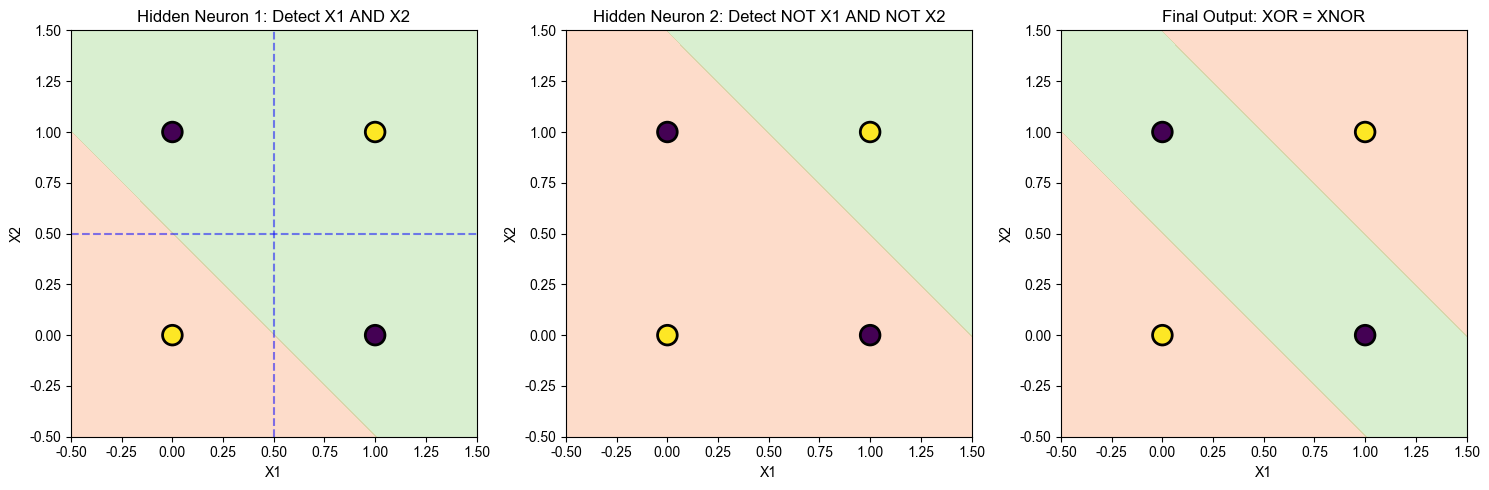


可视化已保存！


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 创建网格
x1_range = np.linspace(-0.5, 1.5, 100)
x2_range = np.linspace(-0.5, 1.5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# 准备网格点
grid_points = torch.tensor(np.column_stack([X1.ravel(), X2.ravel()]), dtype=torch.float32)

# 第一层的决策边界（Hidden Neuron 1和2）
z1_grid = torch.matmul(grid_points, model.W1.T) + model.b1.T
h1_grid = (z1_grid[:, 0] > 0).reshape(X1.shape).numpy()
h2_grid = (z1_grid[:, 1] > 0).reshape(X1.shape).numpy()

# 最终Output的决策边界
h_grid = torch.tensor(np.column_stack([h1_grid.ravel(), h2_grid.ravel()]), dtype=torch.float32)
z2_grid = torch.matmul(h_grid, model.W2) + model.b2
y_grid = (z2_grid[:, 0] > 0).reshape(X1.shape).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 子图1：Hidden Neuron 1的决策区域
ax1 = axes[0]
ax1.contourf(X1, X2, h1_grid, alpha=0.3, cmap='RdYlGn')
ax1.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.numpy(), s=200, edgecolors='black', linewidth=2)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('Hidden Neuron 1: Detect X1 AND X2')
ax1.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5)
ax1.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5)

# 子图2：Hidden Neuron 2的决策区域
ax2 = axes[1]
ax2.contourf(X1, X2, h2_grid, alpha=0.3, cmap='RdYlGn')
ax2.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.numpy(), s=200, edgecolors='black', linewidth=2)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_title('Hidden Neuron 2: Detect NOT X1 AND NOT X2')

# 子图3：最终Output的决策区域（两个Hidden Neuron组合）
ax3 = axes[2]
ax3.contourf(X1, X2, y_grid, alpha=0.3, cmap='RdYlGn')
ax3.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.numpy(), s=200, edgecolors='black', linewidth=2)
ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_title('Final Output: XOR = XNOR')

plt.tight_layout()
plt.savefig('hidden_layer_xor_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n可视化已保存！")

---

## 今日总结

| 概念 | 含义 |
|------|------|
| 隐藏层 | 位于输入和输出之间的「中间层」，负责特征变换 |
| 空间变换 | 隐藏层把线性不可分的问题变换到线性可分的空间 |
| 多层叠加 | 两层感知机（1隐藏层）就能解决 XOR |
| 两条决策边界 | 隐藏层中的每个神经元学一条直线，组合后形成复杂边界 |

**关键洞察**：单层感知机只能画**一条直线**，但加上隐藏层后，就有了**多条直线组合**的能力。

**明天预告**：我们用的阶跃函数太「硬」了——要么 0，要么 1，没有中间地带。明天学习**非线性激活函数**（Sigmoid/ReLU），让神经网络学会「柔和」的决策。